<a href="https://colab.research.google.com/github/teodoraztodorovic/PDU/blob/main/analiza_baze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install -q pydicom

import os
import zipfile
import plistlib
from collections import Counter
import random
import numpy as np
from matplotlib.path import Path
import pandas as pd
import matplotlib.pyplot as plt
import pydicom
from matplotlib.patches import Polygon as MplPolygon

from google.colab import drive


In [2]:
drive.mount('/content/drive')

project_dir = '/content/drive/MyDrive/PDU'
dataset_zip = f'{project_dir}/INBreast.zip'
extract_dir = '/content/INBreast'

if not os.path.isdir(extract_dir):
    with zipfile.ZipFile(dataset_zip, 'r') as zip_file:
        zip_file.extractall(extract_dir)
    print('Raspakovano u:', extract_dir)
else:
    print('Fajlovi već postoje u:', extract_dir)


Mounted at /content/drive
Raspakovano u: /content/INBreast


In [3]:
for root, dirs, files in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = '  ' * (level + 1)
    for f in files[:10]:
        print(f'{subindent}{f}')
    if len(files) > 10:
        print(f'{subindent}... i još {len(files)-10} fajlova')


INBreast/
  INBreast/
    inbreast.pdf
    INbreast.csv
    INbreast.xls
    README.txt
    AllROI/
      22613702.roi
      24055149.roi
      20588020.roi
      53580692.roi
      53586869.roi
      53587041.roi
      30011850.roi
      30011727.roi
      50996827.roi
      24065289.roi
      ... i još 333 fajlova
    AllXML/
      22670465.xml
      20587372.xml
      22579754.xml
      50996406.xml
      53582476.xml
      50994616.xml
      24065434.xml
      53586751.xml
      22613970.xml
      20588308.xml
      ... i još 333 fajlova
    PectoralMuscle/
      Pectoral Muscle XML/
        53581237_muscle.xml
        30011553_muscle.xml
        53581006_muscle.xml
        53582710_muscle.xml
        24058712_muscle.xml
        50996800_muscle.xml
        22614568_muscle.xml
        50997597_muscle.xml
        50997080_muscle.xml
        53586869_muscle.xml
        ... i još 191 fajlova
      Pectoral Muscle ROI/
        50996800_muscle.roi
        50996201_muscle.roi
        5104

In [4]:
csv_path = '/content/INBreast/INBreast/INbreast.csv'

try:
    df = pd.read_csv(csv_path, sep=';')
    if df.shape[1] == 1:
        raise ValueError('Verovatno pogrešan separator')
except (ValueError, pd.errors.ParserError):
    df = pd.read_csv(csv_path, sep=',')

print(df.columns.tolist())
df.head()


['Patient ID', 'Patient age', 'Laterality', 'View', 'Acquisition date', 'File Name', 'ACR', 'Bi-Rads']


,Patient ID,Patient age,Laterality,View,Acquisition date,File Name,ACR,Bi-Rads
0,removed,removed,R,CC,201001,22678622,4,1
1,removed,removed,L,CC,201001,22678646,4,3
2,removed,removed,R,MLO,201001,22678670,4,1
3,removed,removed,L,MLO,201001,22678694,4,3
4,removed,removed,R,CC,201001,22614074,2,5


In [5]:
annotations_dir = os.path.join(extract_dir, 'INBreast/AllXML')
dicom_dir = os.path.join(extract_dir, 'INBreast/AllDICOMs')

def extract_mass_polygons(xml_path):
    with open(xml_path, 'rb') as f:
        annotation = plistlib.load(f)
    rois = annotation['Images'][0]['ROIs']
    return [
        [eval(point) for point in roi['Point_px']]
        for roi in rois if roi.get('Name') == 'Mass'
    ]

mass_counts = {}
for filename in os.listdir(annotations_dir):
    if not filename.endswith('.xml'):
        continue
    polygons = extract_mass_polygons(os.path.join(annotations_dir, filename))
    mass_counts[filename] = len(polygons)

case_ids = [name.replace('.xml', '') for name, count in mass_counts.items() if count > 0]

case_to_dicom_file = {}
for filename in os.listdir(dicom_dir):
    case_id = filename.split('_')[0]
    if case_id in case_ids:
        case_to_dicom_file[case_id] = filename

case_to_patient = {
    case_id: filename.split('_')[1]
    for case_id, filename in case_to_dicom_file.items()
}
patient_ids = [case_to_patient[cid] for cid in case_ids if cid in case_to_patient]

n_unique_patients = len(set(patient_ids))
counts = Counter(patient_ids)
multi = {p: c for p, c in counts.items() if c > 1}

print(f'Slucajeva sa masom: {len(case_ids)}')
print(f'BROJ JEDINSTVENIH PACIJENATA (sa masom): {n_unique_patients}')
print(f'Pacijenata sa >1 slike sa masom: {len(multi)}')
print(f'Detalji: {multi}')


Slucajeva sa masom: 107
BROJ JEDINSTVENIH PACIJENATA (sa masom): 50
Pacijenata sa >1 slike sa masom: 48
Detalji: {'7e677f3d530e41ed': 2, '6aba0b402889a16f': 2, '493155e17143edef': 2, '809e3f43339f93c6': 2, 'bf1a6aaadb05e3df': 2, '465aa5ec1b59efc6': 2, '5eae9beae14d26fd': 4, 'fbb55bf7fff48540': 2, '024ee3569b2605dc': 2, 'b231a8ba4dd4214f': 2, '5291e1aee2bbf5df': 2, '5530d5782fc89dd7': 2, 'd8205a09c8173f44': 2, 'fe7d005dcbbfb46d': 4, '2dec4948fbe6336d': 2, 'a78eba834ef6ee88': 2, '8dbbd4e51f549ff0': 2, 'c4b995eddb3c510c': 2, '6c613a14b80a8591': 4, 'bbd6a3a35438c11b': 2, '1e10aef17c9fe149': 2, 'f4b2d377f43ba0bd': 2, 'd713ef5849f98b6c': 2, '45c7f44839fd9e68': 2, '8c105bb715bf1c3c': 2, 'e15a16f87b4f9782': 2, '0c735e8768d276b4': 2, '349323117bf0fd93': 2, 'f62fbf38fb208316': 2, 'e1f51192f7bf3f5f': 2, 'ac3185e18ffdc7b6': 4, '0b7396cdccacca82': 2, '81cd83d2f4d78528': 2, '6200187f3f1ccc18': 2, '6ac23356b912ee9b': 2, '1e5c3af078f74b05': 2, '98429c0bdf78c0c7': 2, '61b13c59bcba149e': 2, '51bec6477a7

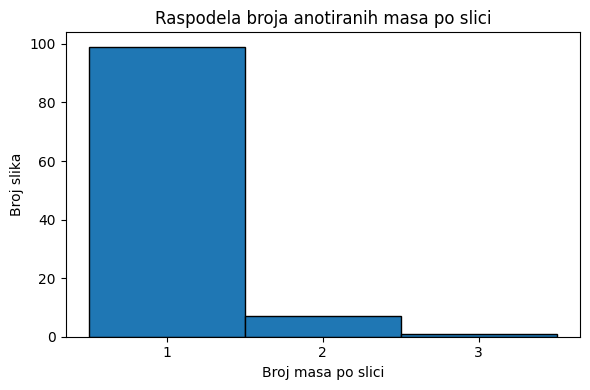

In [6]:
mass_per_image = [c for c in mass_counts.values() if c > 0]

plt.figure(figsize=(6, 4))
plt.hist(mass_per_image, bins=range(1, max(mass_per_image) + 2), edgecolor='black', align='left')
plt.xlabel('Broj masa po slici')
plt.ylabel('Broj slika')
plt.title('Raspodela broja anotiranih masa po slici')
plt.xticks(range(1, max(mass_per_image) + 1))
plt.tight_layout()
plt.show()


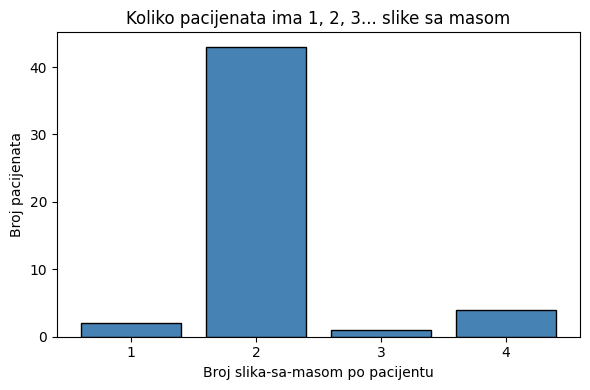

Pregled: {1: 2, 2: 43, 3: 1, 4: 4}


In [7]:
images_per_patient = Counter(counts.values())

plt.figure(figsize=(6, 4))
plt.bar(images_per_patient.keys(), images_per_patient.values(), color='steelblue', edgecolor='black')
plt.xlabel('Broj slika-sa-masom po pacijentu')
plt.ylabel('Broj pacijenata')
plt.title('Koliko pacijenata ima 1, 2, 3... slike sa masom')
plt.xticks(list(images_per_patient.keys()))
plt.tight_layout()
plt.show()

print('Pregled:', dict(sorted(images_per_patient.items())))


In [8]:
summary = pd.DataFrame({
    'Metrika': [
        'Ukupno slika u XML anotacijama',
        'Slika sa bar jednom masom',
        'Jedinstvenih pacijenata sa masom',
        'Pacijenata sa >1 slikom-sa-masom',
        'Prosečan broj masa po slici (gde ima mase)'
    ],
    'Vrednost': [
        len(mass_counts),
        len(case_ids),
        n_unique_patients,
        len(multi),
        round(sum(mass_per_image) / len(mass_per_image), 2) if mass_per_image else 0
    ]
})
summary


,Metrika,Vrednost
0,Ukupno slika u XML anotacijama,343.00
1,Slika sa bar jednom masom,107.00
2,Jedinstvenih pacijenata sa masom,50.00
3,Pacijenata sa >1 slikom-sa-masom,48.00
4,Prosečan broj masa po slici (gde ima mase),1.08


<>:6: SyntaxWarning: invalid escape sequence '\P'
<>:6: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_408/235154269.py:6: SyntaxWarning: invalid escape sequence '\P'
  print(f'\Pacijent {patient_id} — {len(cases)} slika(e)')


\Pacijent 98429c0bdf78c0c7 — 2 slika(e)


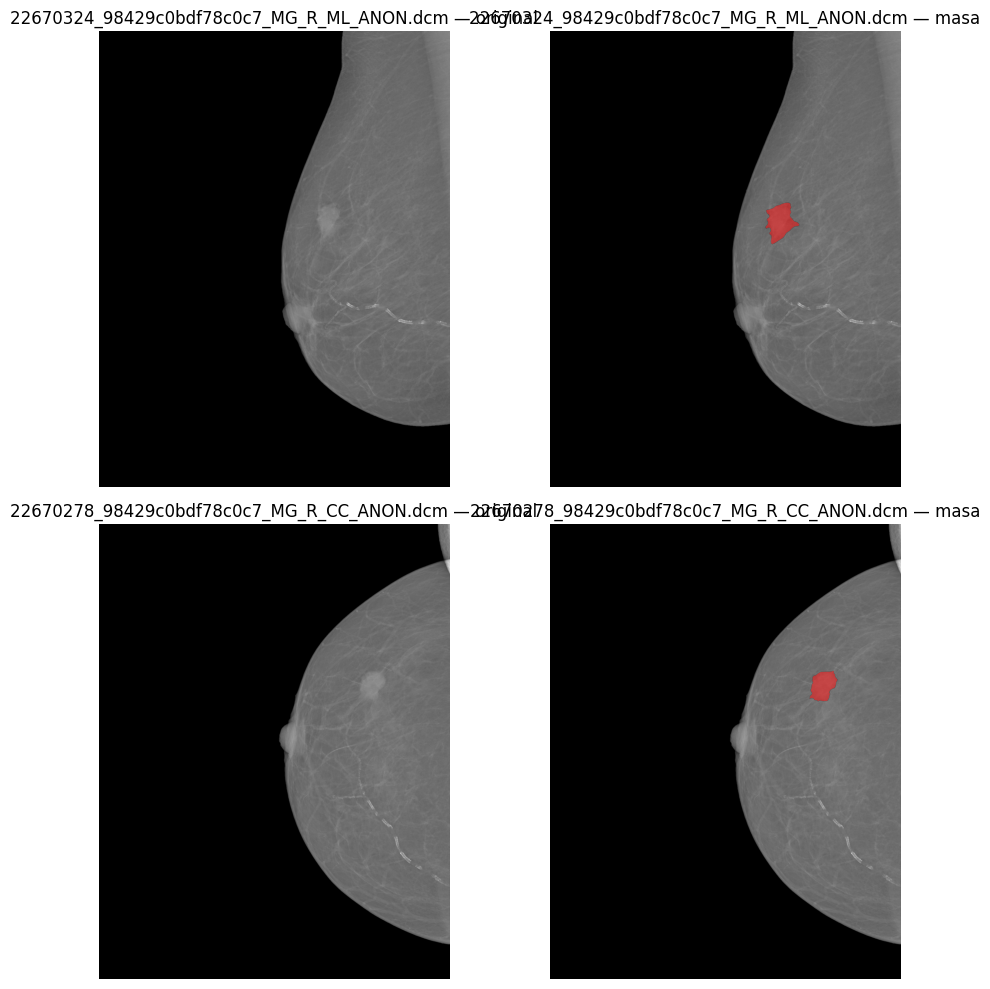

\Pacijent 1e5c3af078f74b05 — 2 slika(e)


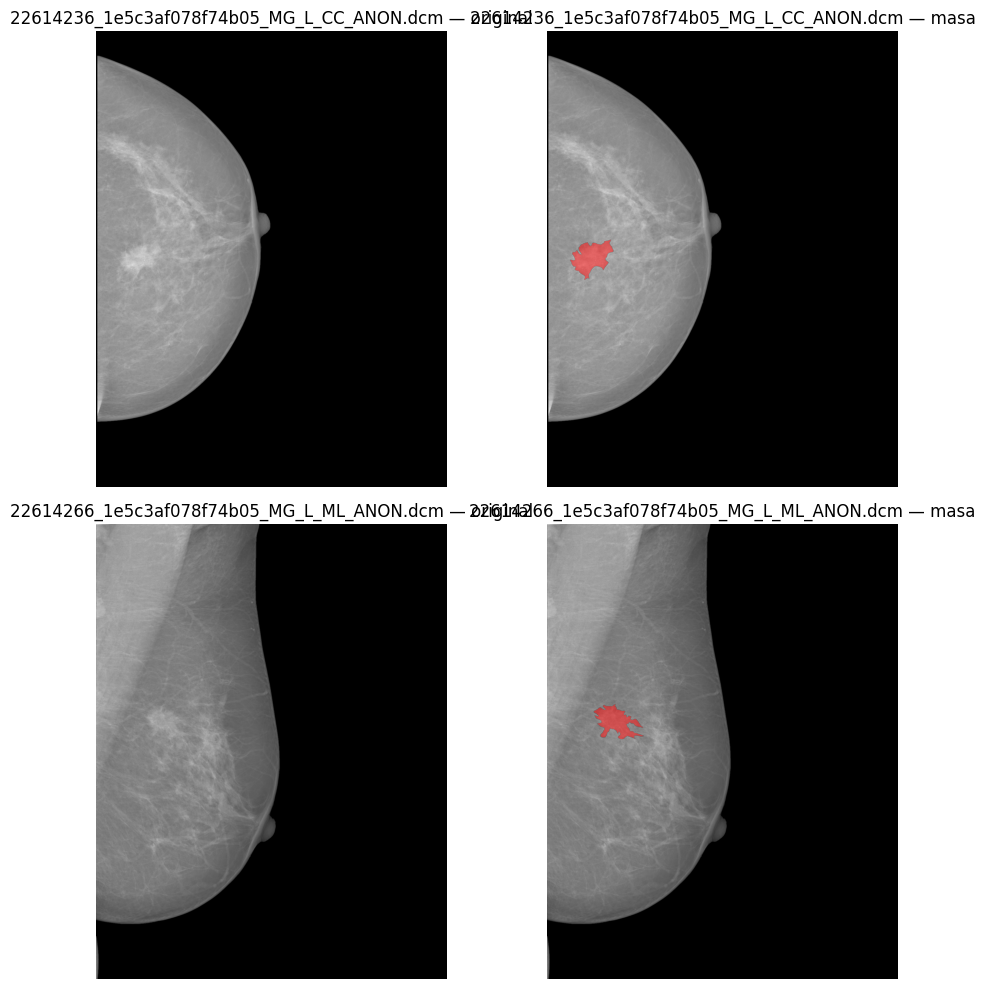

\Pacijent 64a22c47765f0c5c — 2 slika(e)


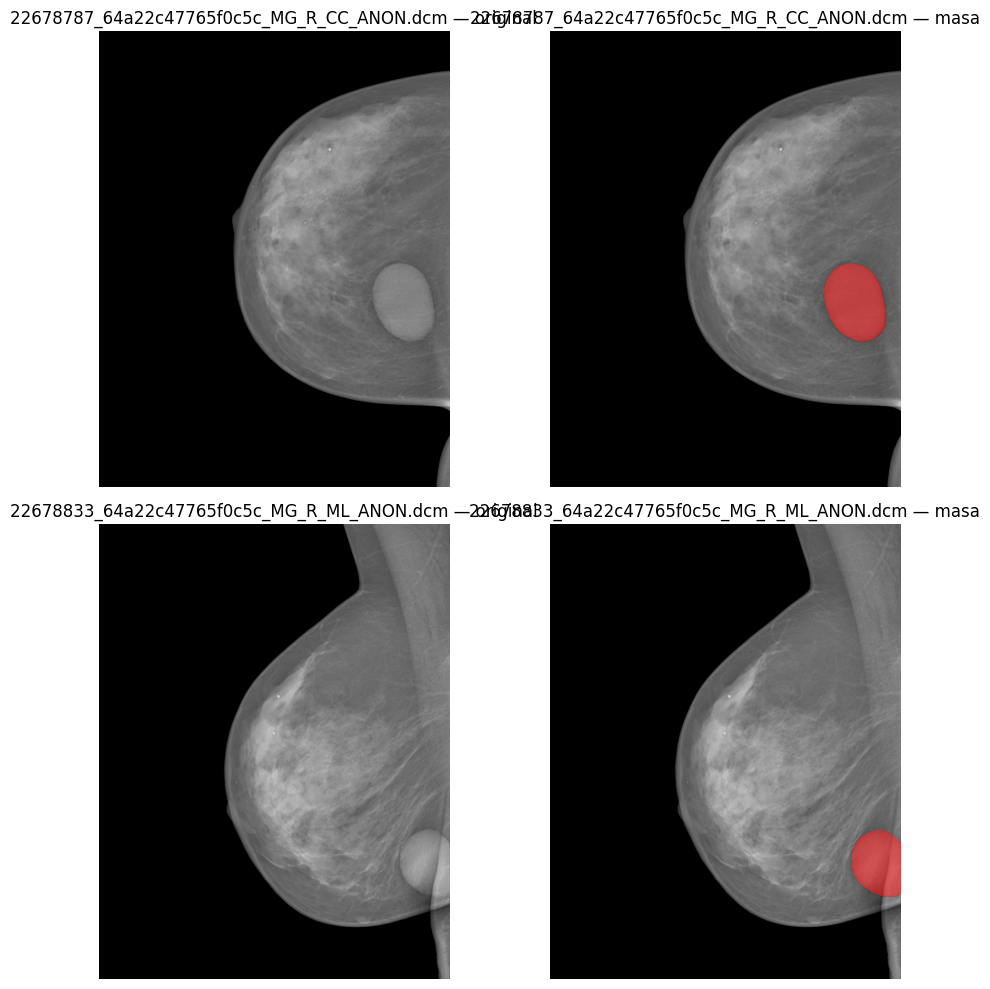

\Pacijent f4b2d377f43ba0bd — 2 slika(e)


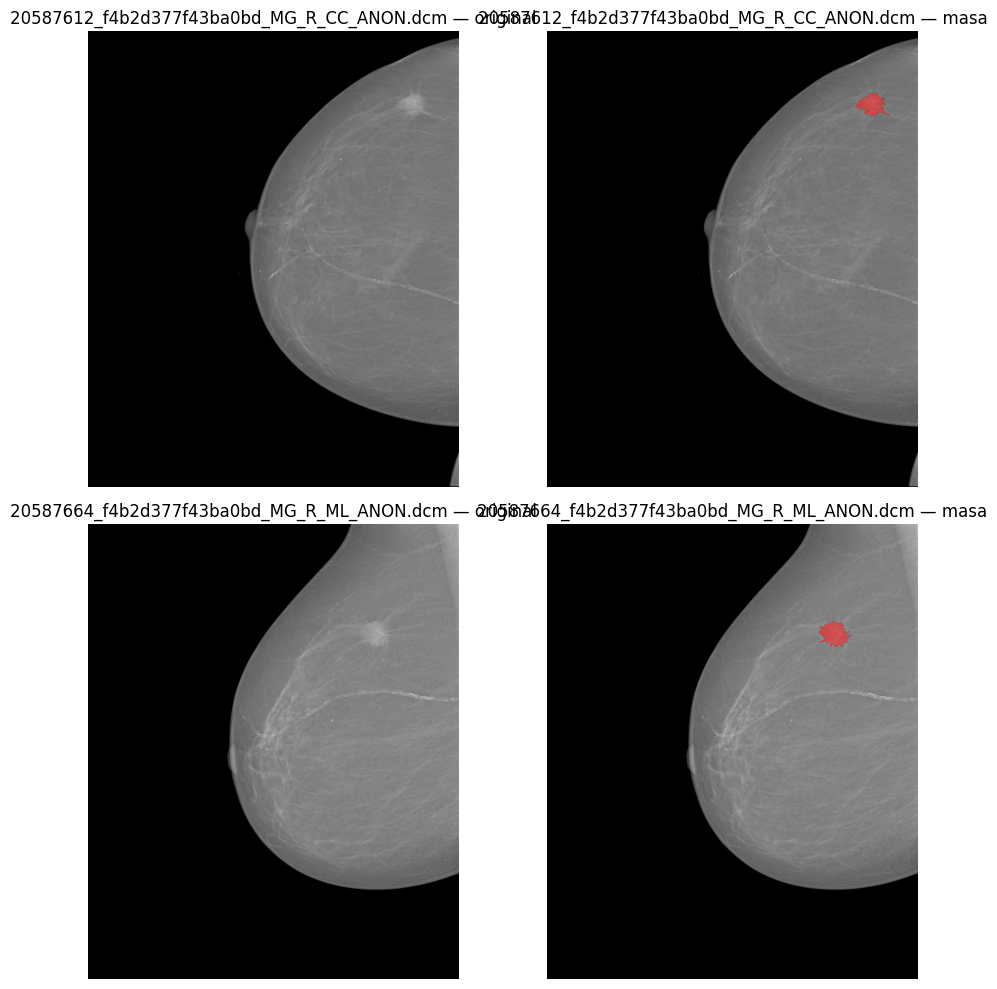

In [17]:
random.seed()
sample_patients = random.sample(list(patient_to_cases.keys()), 4)

for patient_id in sample_patients:
    cases = patient_to_cases[patient_id]
    print(f'\Pacijent {patient_id} — {len(cases)} slika(e)')

    fig, axes = plt.subplots(len(cases), 2, figsize=(10, 5 * len(cases)))
    if len(cases) == 1:
        axes = [axes]

    for row, case_id in zip(axes, cases):
        dicom_path = os.path.join(dicom_dir, case_to_dicom_file[case_id])
        img = pydicom.dcmread(dicom_path).pixel_array

        h, w = img.shape
        yy, xx = np.mgrid[0:h, 0:w]
        points = np.vstack((xx.ravel(), yy.ravel())).T
        mask = np.zeros((h, w), dtype=bool)
        for polygon in case_to_polygons[case_id]:
            path = Path(polygon)
            mask |= path.contains_points(points).reshape(h, w)

        ax_clean, ax_mask = row
        ax_clean.imshow(img, cmap='gray')
        ax_clean.set_title(f'{case_to_dicom_file[case_id]} — original')
        ax_clean.axis('off')

        ax_mask.imshow(img, cmap='gray')
        ax_mask.imshow(np.ma.masked_where(~mask, mask), cmap='autumn', alpha=0.5)
        ax_mask.set_title(f'{case_to_dicom_file[case_id]} — masa')
        ax_mask.axis('off')

    plt.tight_layout()
    plt.show()